# Question 3: Numerical Integration of $f(x) = e^{x^2}$ on $(0, 1)$

We compute $\displaystyle\int_0^1 e^{x^2}\, dx$ using the **trapezoidal rule**, **Simpson's rule**, and **Gaussian quadrature**, then compare the results.

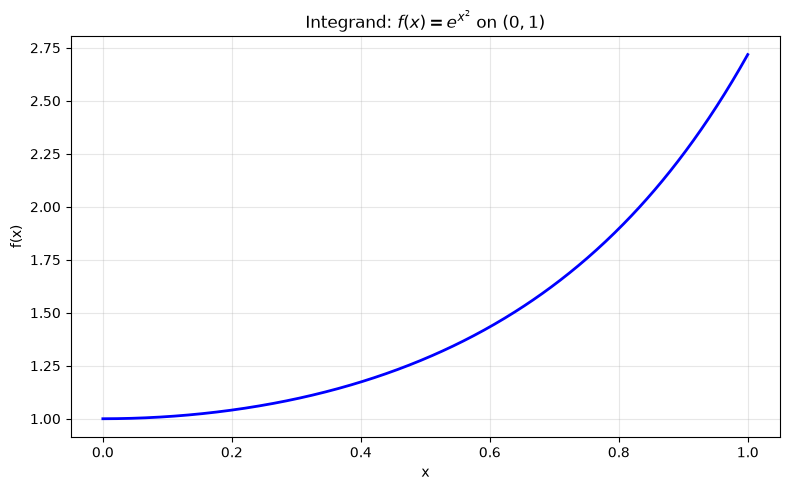

In [ ]:
import numpy as np
from numpy.polynomial.legendre import leggauss
from scipy import integrate
import matplotlib.pyplot as plt

def f(x):
    return np.exp(np.power(x, 2))

# Plot the integrand on (0, 1)
x_plot = np.linspace(1e-6, 1, 500)
plt.figure(figsize=(8, 5))
plt.plot(x_plot, f(x_plot), 'b-', linewidth=2)
plt.xlabel('x')
plt.ylabel('f(x)')
plt.title(r'Integrand: $f(x) = e^{x^2}$ on $(0, 1)$')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 3(a) Trapezoidal Rule and Simpson's Rule

In [ ]:
def trapezoidal(f, a, b, n):
    x = np.linspace(a, b, n + 1)
    y = f(x)
    h = (b - a) / n
    return h / 2 * (y[0] + 2 * np.sum(y[1:-1]) + y[-1])


def simpson(f, a, b, n):
    if n % 2 != 0:
        n += 1
    x = np.linspace(a, b, n + 1)
    y = f(x)
    h = (b - a) / n
    return h / 3 * (y[0] + y[-1] + 4 * np.sum(y[1:-1:2]) + 2 * np.sum(y[2:-1:2]))


a, b = 0, 1
n = 1000  # number of subintervals

I_trap = trapezoidal(f, a, b, n)
I_simp = simpson(f, a, b, n)

print(f"Trapezoidal rule  (n = {n}):  I ≈ {I_trap:.12f}")
print(f"Simpson's rule    (n = {n}):  I ≈ {I_simp:.12f}")

Trapezoidal rule  (n = 1000):  I ≈ 1.462652198954
Simpson's rule    (n = 1000):  I ≈ 1.462651745907


### Convergence Study

The table below shows how the trapezoidal and Simpson approximations converge as the number of subintervals increases.

In [15]:
# Reference value from adaptive Gaussian quadrature (scipy)
I_ref, ref_err = integrate.quad(lambda x: float(f(x)), a, b, epsabs=1e-14, epsrel=1e-14)
print(f"Reference (adaptive quadrature): I = {I_ref:.12f}  (error estimate: {ref_err:.2e})\n")

subintervals = [10, 20, 50, 100, 200, 500, 1000]
print(f"{'n':>6}  {'Trapezoidal':>16}  {'|Error|':>12}  {'Simpson':>16}  {'|Error|':>12}")
print("-" * 70)
for n in subintervals:
    t = trapezoidal(f, a, b, n)
    s = simpson(f, a, b, n)
    print(f"{n:6d}  {t:16.10f}  {abs(t - I_ref):12.2e}  {s:16.10f}  {abs(s - I_ref):12.2e}")

Reference (adaptive quadrature): I = 1.462651745907  (error estimate: 1.62e-14)

     n       Trapezoidal       |Error|           Simpson       |Error|
----------------------------------------------------------------------
    10      1.4671746927      4.52e-03      1.4626814001      2.97e-05
    20      1.4637838918      1.13e-03      1.4626536249      1.88e-06
    50      1.4628329526      1.81e-04      1.4626517942      4.83e-08
   100      1.4626970498      4.53e-05      1.4626517489      3.02e-09
   200      1.4626630720      1.13e-05      1.4626517461      1.89e-10
   500      1.4626535581      1.81e-06      1.4626517459      4.83e-12
  1000      1.4626521990      4.53e-07      1.4626517459      3.02e-13


C:\Users\mehra\AppData\Local\Temp\ipykernel_2544\1021093209.py:2: IntegrationWarning: The occurrence of roundoff error is detected, which prevents 
  the requested tolerance from being achieved.  The error may be 
  underestimated.
  I_ref, ref_err = integrate.quad(lambda x: float(f(x)), a, b, epsabs=1e-14, epsrel=1e-14)


## 3(b) Gaussian Quadrature

Gauss-Legendre quadrature approximates the integral using optimally chosen nodes and weights on $[-1, 1]$, then maps to $[a, b]$:

$$\int_a^b f(x)\,dx \approx \frac{b-a}{2} \sum_{i=1}^{n} w_i \, f\!\left(\frac{b-a}{2}\xi_i + \frac{a+b}{2}\right)$$

In [ ]:
def gauss_legendre(f, a, b, n):
    nodes, weights = leggauss(n)
    # Transform from [-1, 1] to [a, b]
    x_mapped = 0.5 * (b - a) * nodes + 0.5 * (a + b)
    return 0.5 * (b - a) * np.sum(weights * f(x_mapped))


# Compute with different numbers of Gauss nodes
for n_nodes in [5, 10, 20, 50]:
    I_gauss = gauss_legendre(f, a, b, n_nodes)
    print(f"Gauss-Legendre (n = {n_nodes:2d} nodes): I ≈ {I_gauss:.12f}  |error| = {abs(I_gauss - I_ref):.2e}")

I_gauss_final = gauss_legendre(f, a, b, 50)

Gauss-Legendre (n =  5 nodes): I ≈ 1.462651668019  |error| = 7.79e-08
Gauss-Legendre (n = 10 nodes): I ≈ 1.462651745907  |error| = 2.22e-16
Gauss-Legendre (n = 20 nodes): I ≈ 1.462651745907  |error| = 6.66e-16
Gauss-Legendre (n = 50 nodes): I ≈ 1.462651745907  |error| = 1.11e-15


## Comparison of All Methods

In [17]:
I_trap_final = trapezoidal(f, a, b, 1000)
I_simp_final = simpson(f, a, b, 1000)

results = {
    'Trapezoidal (n=1000)': I_trap_final,
    "Simpson's (n=1000)": I_simp_final,
    'Gauss-Legendre (n=50)': I_gauss_final,
    'Adaptive Quadrature (reference)': I_ref,
}

print(f"{'Method':<35} {'Integral Value':>18}  {'|Error|':>12}")
print("-" * 68)
for method, value in results.items():
    err = abs(value - I_ref) if method != 'Adaptive Quadrature (reference)' else 0.0
    print(f"{method:<35} {value:18.10f}  {err:12.2e}")

Method                                  Integral Value       |Error|
--------------------------------------------------------------------
Trapezoidal (n=1000)                      1.4626521990      4.53e-07
Simpson's (n=1000)                        1.4626517459      3.02e-13
Gauss-Legendre (n=50)                     1.4626517459      1.11e-15
Adaptive Quadrature (reference)           1.4626517459      0.00e+00
